2026-04-18 23:32:20.282135: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


🧠 ОБУЧЕНИЕ НЕЙРОСЕТИ ДЛЯ NNI

📊 Генерация данных...
✅ Сгенерировано точек: 110,000

📏 Нормализация данных...
✅ Скейлеры сохранены: scaler_X.pkl, scaler_y.pkl

🏗️ Построение нейросети...
🧠 Архитектура: 7 слоев (1024→512→512→256→256→128→64)
📊 Параметров: 1,041,665

🚀 Обучение модели...
Epoch 1/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 0.2937 - mae: 0.3212 - val_loss: 0.7351 - val_mae: 0.7239
Epoch 2/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.0319 - mae: 0.1353 - val_loss: 0.5344 - val_mae: 0.6317
Epoch 3/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.0291 - mae: 0.1290 - val_loss: 0.1128 - val_mae: 0.2783
Epoch 4/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.0232 - mae: 0.1144 - val_loss: 0.0117 - val_mae: 0.0841
Epoch 5/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0226 - mae: 0.1137 - val_loss: 0.0058 - val_mae: 0.0584
Epoch 6/200
183/183 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0200 - mae: 0.1070 - val_loss: 0.0105 - val_mae: 0

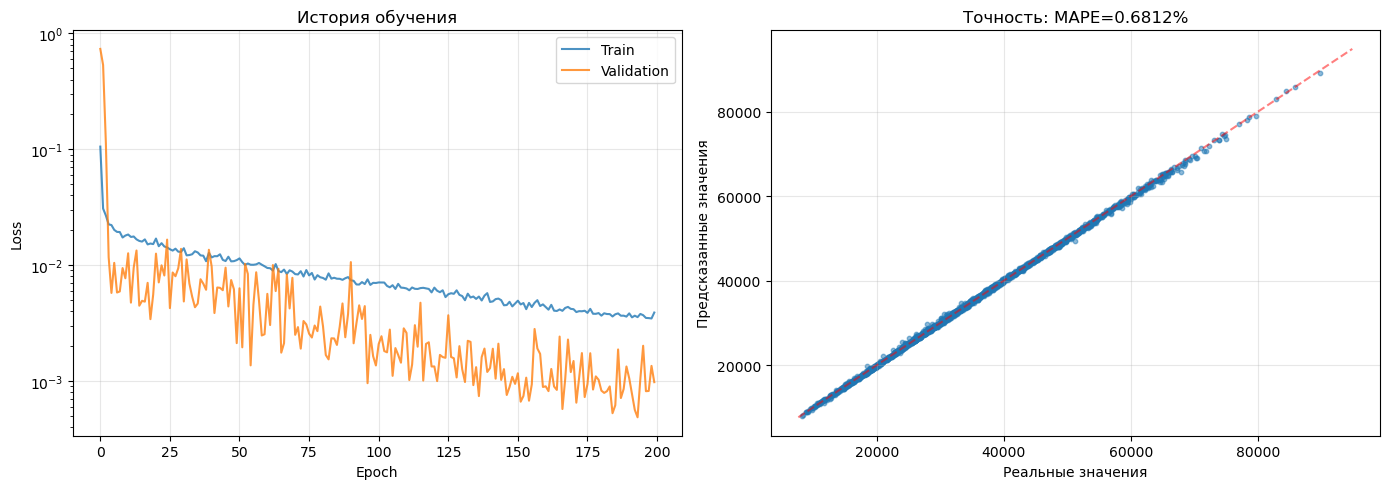


✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!

📁 Созданные файлы:
   • nnn_model.keras - обученная нейросеть
   • scaler_X.pkl - скейлер для входных данных
   • scaler_y.pkl - скейлер для выходных данных
   • training_results.png - график обучения

💡 Теперь можно запускать test_nni.py


In [1]:
# ==================== ЧАСТЬ 1: ОБУЧЕНИЕ МОДЕЛИ ====================
# Запустите этот файл ОДИН РАЗ для обучения модели
# После обучения создадутся файлы: model.keras, scaler_X.pkl, scaler_y.pkl

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
tf.keras.backend.set_floatx('float64')

print("="*70)
print("🧠 ОБУЧЕНИЕ НЕЙРОСЕТИ ДЛЯ NNI")
print("="*70)

# ==================== ПАРАМЕТРЫ ====================
n = 4
# РАСШИРЕННЫЕ границы обучения
a_train = np.array([20.0, 1.0, 0.0, -40.0])
b_train = np.array([350.0, 7.0, 800.0, 40.0])

def aviation_revenue(X):
    """Целевая функция (доход авиакомпании)"""
    X = np.atleast_2d(X)
    p, w, h, hol = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    base = 1000.0 * np.exp(-0.01 * p)
    f_day = 1.0 + 0.3 * np.sin((w - 1) * np.pi / 3.5)
    f_hour = 1.0 + 0.5 * np.exp(-h / 200.0)
    f_hol = 1.0 + 0.4 * np.exp(-np.abs(hol) / 10.0)
    return p * (base * f_day * f_hour * f_hol)

# ==================== ГЕНЕРАЦИЯ ДАННЫХ ====================
print("\n📊 Генерация данных...")

np.random.seed(42)
N_points = 50000

# 1. Равномерная выборка
X_uniform = np.random.uniform(a_train, b_train, (N_points, n))

# 2. Выборка с акцентом на тестовые диапазоны
X_test_regions = []
test_p_ranges = [(50, 300), (80, 120), (200, 300), (50, 100), (100, 200)]
for p_min, p_max in test_p_ranges:
    region_points = N_points // len(test_p_ranges)
    X_region = np.random.uniform(a_train, b_train, (region_points, n))
    X_region[:, 0] = np.random.uniform(p_min, p_max, region_points)
    X_test_regions.append(X_region)

X_important = np.vstack(X_test_regions)

# 3. Сетка для точности
grid_points = []
for p in [80, 100, 150, 200, 250]:
    X_grid = np.random.uniform(a_train, b_train, (2000, n))
    X_grid[:, 0] = p + np.random.normal(0, 5, 2000)
    grid_points.append(X_grid)

X_grid_all = np.vstack(grid_points)

# Объединяем все данные
X_raw = np.vstack([X_uniform, X_important, X_grid_all])
y_raw = aviation_revenue(X_raw).reshape(-1, 1)

print(f"✅ Сгенерировано точек: {len(X_raw):,}")

# ==================== НОРМАЛИЗАЦИЯ ====================
print("\n📏 Нормализация данных...")
scaler_X = StandardScaler().fit(X_raw)
scaler_y = StandardScaler().fit(y_raw)
X_norm = scaler_X.transform(X_raw)
y_norm = scaler_y.transform(y_raw).flatten()

# Сохраняем скейлеры
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print("✅ Скейлеры сохранены: scaler_X.pkl, scaler_y.pkl")

# ==================== НЕЙРОСЕТЬ ====================
print("\n🏗️ Построение нейросети...")

inputs = Input(shape=(n,))

x = Dense(1024, activation='swish')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)

x = Dense(512, activation='swish')(x)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)

x = Dense(512, activation='swish')(x)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)

x = Dense(256, activation='swish')(x)
x = BatchNormalization()(x)
x = Dropout(0.05)(x)

x = Dense(256, activation='swish')(x)
x = BatchNormalization()(x)

x = Dense(128, activation='swish')(x)
x = BatchNormalization()(x)

x = Dense(64, activation='swish')(x)
outputs = Dense(1, activation='linear')(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

print(f"🧠 Архитектура: 7 слоев (1024→512→512→256→256→128→64)")
print(f"📊 Параметров: {model.count_params():,}")

# ==================== ОБУЧЕНИЕ ====================
print("\n🚀 Обучение модели...")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

history = model.fit(
    X_norm, y_norm,
    batch_size=512,
    epochs=200,
    verbose=1,
    validation_split=0.15,
    callbacks=callbacks
)

# Загружаем лучшие веса
model.load_weights('best_model.keras')

# Сохраняем финальную модель
model.save('nnn_model.keras')
print("\n✅ Модель сохранена: nnn_model.keras")

# ==================== ОЦЕНКА КАЧЕСТВА ====================
print("\n📊 Оценка качества...")
y_pred_norm = model.predict(X_norm, verbose=0).flatten()
y_pred = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
mape = np.mean(np.abs((y_raw.flatten() - y_pred) / y_raw.flatten())) * 100
r2 = 1 - np.sum((y_raw.flatten() - y_pred)**2) / np.sum((y_raw.flatten() - y_raw.mean())**2)

print(f"   MAPE: {mape:.4f}%")
print(f"   R²: {r2:.6f}")

# ==================== ВИЗУАЛИЗАЦИЯ ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train', alpha=0.8)
axes[0].plot(history.history['val_loss'], label='Validation', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('История обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

test_idx = np.random.choice(len(X_raw), 2000, replace=False)
axes[1].scatter(y_raw[test_idx], y_pred[test_idx], alpha=0.5, s=10)
axes[1].plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--', alpha=0.5)
axes[1].set_xlabel('Реальные значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].set_title(f'Точность: MAPE={mape:.4f}%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()

print("\n" + "="*70)
print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("="*70)
print("\n📁 Созданные файлы:")
print("   • nnn_model.keras - обученная нейросеть")
print("   • scaler_X.pkl - скейлер для входных данных")
print("   • scaler_y.pkl - скейлер для выходных данных")
print("   • training_results.png - график обучения")
print("\n💡 Теперь можно запускать test_nni.py")